In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns

In [2]:
#Langkah 1: Memuat dataset iris menggunakan seaborn.load_dataset(). Tampilkan shape, dtypes, head(), dan .describe().

print("\n==== Load & Inspect Dataset ====\n")

df = sns.load_dataset('iris')

print('Shape:', df.shape)
print('\n Tipe Data:')
print(df.dtypes)

print('\n 5 Data Teratas:')
print(df.head())

print('\n Statistika Deskriptif:')
print(df.describe().round(3))


==== Load & Inspect Dataset ====

Shape: (150, 5)

 Tipe Data:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

 5 Data Teratas:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

 Statistika Deskriptif:
       sepal_length  sepal_width  petal_length  petal_width
count       150.000      150.000       150.000      150.000
mean          5.843        3.057         3.758        1.199
std           0.828        0.436         1.765        0.762
min           4.300        2.000         1.000        0.100
25%           5.100        2.800         1.600        0.300
50%           5

In [3]:
#Langkah 2: Menghitung mean, median, std, varians, skewness, kurtosis untuk setiap kolom numerik.

print("\n==== Statistik Deskriptif Lengkap ====")

for col_name in df.select_dtypes(include='number').columns:
    col = df[col_name]
    print(f'\n=== {col_name} ===')
    print(f'  Mean     : {col.mean():.3f}')
    print(f'  Median   : {col.median():.3f}')
    print(f'  Std Dev  : {col.std():.3f}')
    print(f'  Skewness : {col.skew():.3f}')


==== Statistik Deskriptif Lengkap ====

=== sepal_length ===
  Mean     : 5.843
  Median   : 5.800
  Std Dev  : 0.828
  Skewness : 0.315

=== sepal_width ===
  Mean     : 3.057
  Median   : 3.000
  Std Dev  : 0.436
  Skewness : 0.319

=== petal_length ===
  Mean     : 3.758
  Median   : 4.350
  Std Dev  : 1.765
  Skewness : -0.275

=== petal_width ===
  Mean     : 1.199
  Median   : 1.300
  Std Dev  : 0.762
  Skewness : -0.103



==== Analisis Distribusi (Histogram + KDE) ====



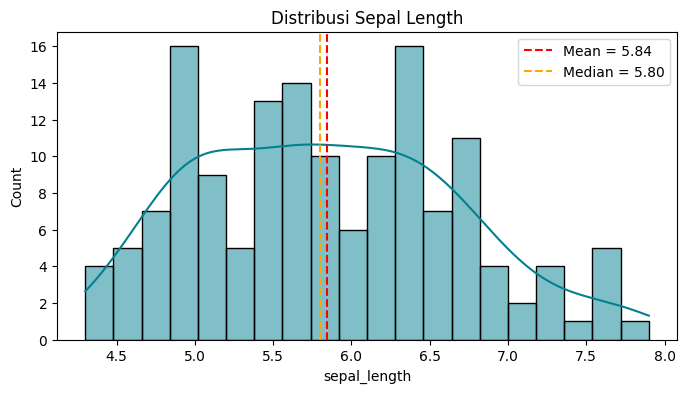

In [6]:
#Langkah 3: Membuat histogram + KDE untuk sepal_length. Tambahkan garis mean dan median. Identifikasi jenis distribusinya.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

# Load dataset iris
iris = load_iris()

# Buat DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Rename kolom supaya lebih mudah dipakai
df.columns = ['sepal_length', 'sepal_width',
              'petal_length', 'petal_width']

# ===============================
# Histogram + KDE
# ===============================

print("\n==== Analisis Distribusi (Histogram + KDE) ====\n")

fig, ax = plt.subplots(figsize=(8, 4))

sns.histplot(
    data=df,
    x='sepal_length',
    kde=True,
    color='#028090',
    bins=20,
    ax=ax
)

# Garis mean
ax.axvline(
    df['sepal_length'].mean(),
    color='red',
    linestyle='--',
    label=f"Mean = {df['sepal_length'].mean():.2f}"
)

# Garis median
ax.axvline(
    df['sepal_length'].median(),
    color='orange',
    linestyle='--',
    label=f"Median = {df['sepal_length'].median():.2f}"
)

ax.set_title('Distribusi Sepal Length')
ax.legend()

plt.show()


==== Boxplot per Spesies ====



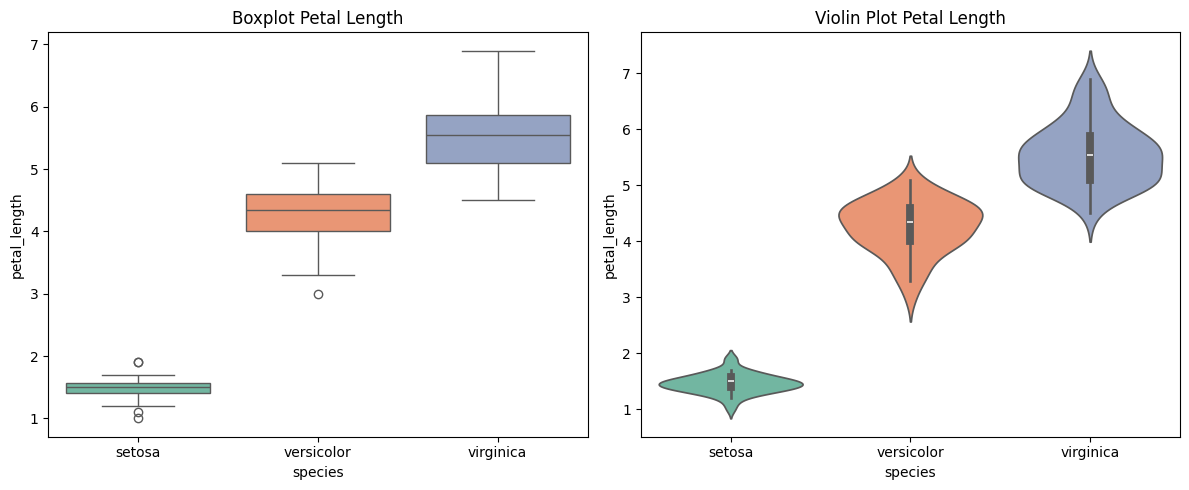

In [8]:
#Langkah 4: Membuat boxplot petal_length per spesies. Identifikasi spesies dengan nilai terbesar, terkecil, dan paling tersebar.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

# Load dataset iris
iris = load_iris()

# Buat DataFrame fitur
df = pd.DataFrame(
    iris.data,
    columns=['sepal_length', 'sepal_width',
             'petal_length', 'petal_width']
)

# Tambahkan kolom species
df['species'] = pd.Categorical.from_codes(
    iris.target,
    iris.target_names
)

# ====================================
# Boxplot dan Violin Plot
# ====================================

print("\n==== Boxplot per Spesies ====\n")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# BOXPLOT
sns.boxplot(
    data=df,
    x='species',
    y='petal_length',
    hue='species',
    palette='Set2',
    ax=axes[0],
    legend=False
)

axes[0].set_title('Boxplot Petal Length')

# VIOLIN PLOT
sns.violinplot(
    data=df,
    x='species',
    y='petal_length',
    hue='species',
    palette='Set2',
    inner='box',
    ax=axes[1],
    legend=False
)

axes[1].set_title('Violin Plot Petal Length')

plt.tight_layout()
plt.show()

In [9]:
#Langkah 5: Menhitung matriks korelasi. Identifikasi pasangan kolom dengan korelasi tertinggi dan terendah.

print("\n==== Matriks Korelasi Pearson ====\n")

corr = df.drop('species', axis=1).corr(method='pearson')
print(corr.round(3))
import numpy as np
mask = np.triu(np.ones(corr.shape, dtype=bool))
corr_masked = corr.where(~mask)
max_pair = corr_masked.stack().idxmax()
min_pair = corr_masked.stack().idxmin()

print('\n Hasilnya sebagai berikut :')
print(f'Korelasi tertinggi: {max_pair} = {corr.loc[max_pair]:.3f}')
print(f'Korelasi terendah: {min_pair} = {corr.loc[min_pair]:.3f}')


==== Matriks Korelasi Pearson ====

              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.118         0.872        0.818
sepal_width         -0.118        1.000        -0.428       -0.366
petal_length         0.872       -0.428         1.000        0.963
petal_width          0.818       -0.366         0.963        1.000

 Hasilnya sebagai berikut :
Korelasi tertinggi: ('petal_width', 'petal_length') = 0.963
Korelasi terendah: ('petal_length', 'sepal_width') = -0.428



==== Scatter Plot & Heatmap ====



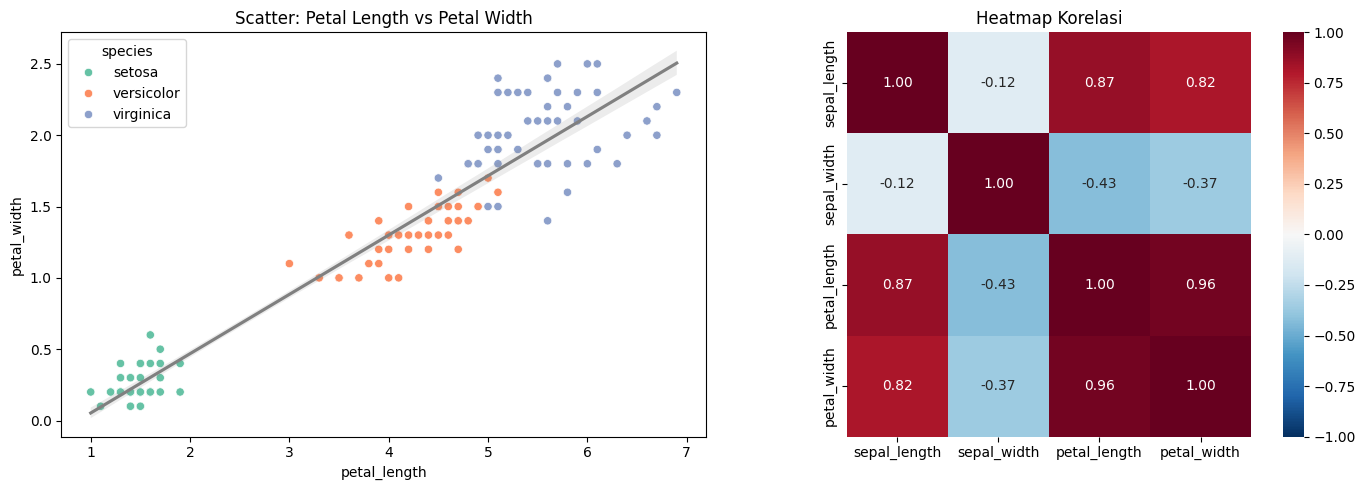

In [10]:
#Langkah 6: Membuat scatter plot pasangan paling berkorelasi + heatmap lengkap. Sertakan narasi interpretasi dalam Markdown.

print("\n==== Scatter Plot & Heatmap ====\n")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df, x='petal_length', y='petal_width',
hue='species', palette='Set2', ax=axes[0])
sns.regplot(data=df, x='petal_length', y='petal_width',
scatter=False, color='gray', ax=axes[0])
axes[0].set_title('Scatter: Petal Length vs Petal Width')
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
vmin=-1, vmax=1, square=True, ax=axes[1])
axes[1].set_title('Heatmap Korelasi')
plt.tight_layout(); plt.show()